In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Load the transformed data
file_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data/transformed/bank_churn_transformed.csv"))
df = pd.read_csv(file_path)

In [3]:
# Display basic info
print("Data Shape:", df.shape)
print("Column Names:", df.columns.tolist())
print("Missing Values:")
print(df.isnull().sum())

Data Shape: (23421, 20)
Column Names: ['Customer_ID', 'Credit_Score', 'Age', 'Tenure', 'Balance', 'Num_Products', 'Has_Credit_Card', 'Is_Active', 'Salary', 'Churn', 'Country_Germany', 'Country_Spain', 'Gender_Male', 'Customer_Tenure_Years', 'Activity_Frequency', 'Avg_Balance_per_Product', 'Credit_Card_Utilization', 'Salary_Normalized', 'Spending_Power_Index', 'High_Value_Customer']
Missing Values:
Customer_ID                    0
Credit_Score               10000
Age                            0
Tenure                         0
Balance                        0
Num_Products                   0
Has_Credit_Card                0
Is_Active                      0
Salary                         0
Churn                          0
Country_Germany            10000
Country_Spain              10000
Gender_Male                10000
Customer_Tenure_Years          0
Activity_Frequency             0
Avg_Balance_per_Product        0
Credit_Card_Utilization        0
Salary_Normalized              0
Spend

In [4]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
        Customer_ID  Credit_Score           Age        Tenure       Balance  \
count  23421.000000  13421.000000  23421.000000  23421.000000  23421.000000   
mean      -0.001449     -0.001462      0.003941      0.003613      0.022322   
std        0.997131      1.015668      1.009208      1.000684      1.001762   
min       -1.779921     -3.624930     -2.336464     -1.791671     -1.225786   
25%       -0.827665     -0.794063     -0.699407     -0.725390     -0.896008   
50%       -0.037275      0.048613     -0.114743     -0.014537      0.239271   
75%        0.906191      0.680620      0.469920      0.696317      0.948107   
max        1.734168      2.523975      5.060944      1.762598      2.795184   

       Num_Products  Has_Credit_Card     Is_Active        Salary  \
count  23421.000000     23421.000000  23421.000000  23421.000000   
mean      -0.002206        -0.005130      0.000999     -0.003633   
std        1.002075         1.003202      0.999993      0.99909

<Figure size 1200x800 with 0 Axes>

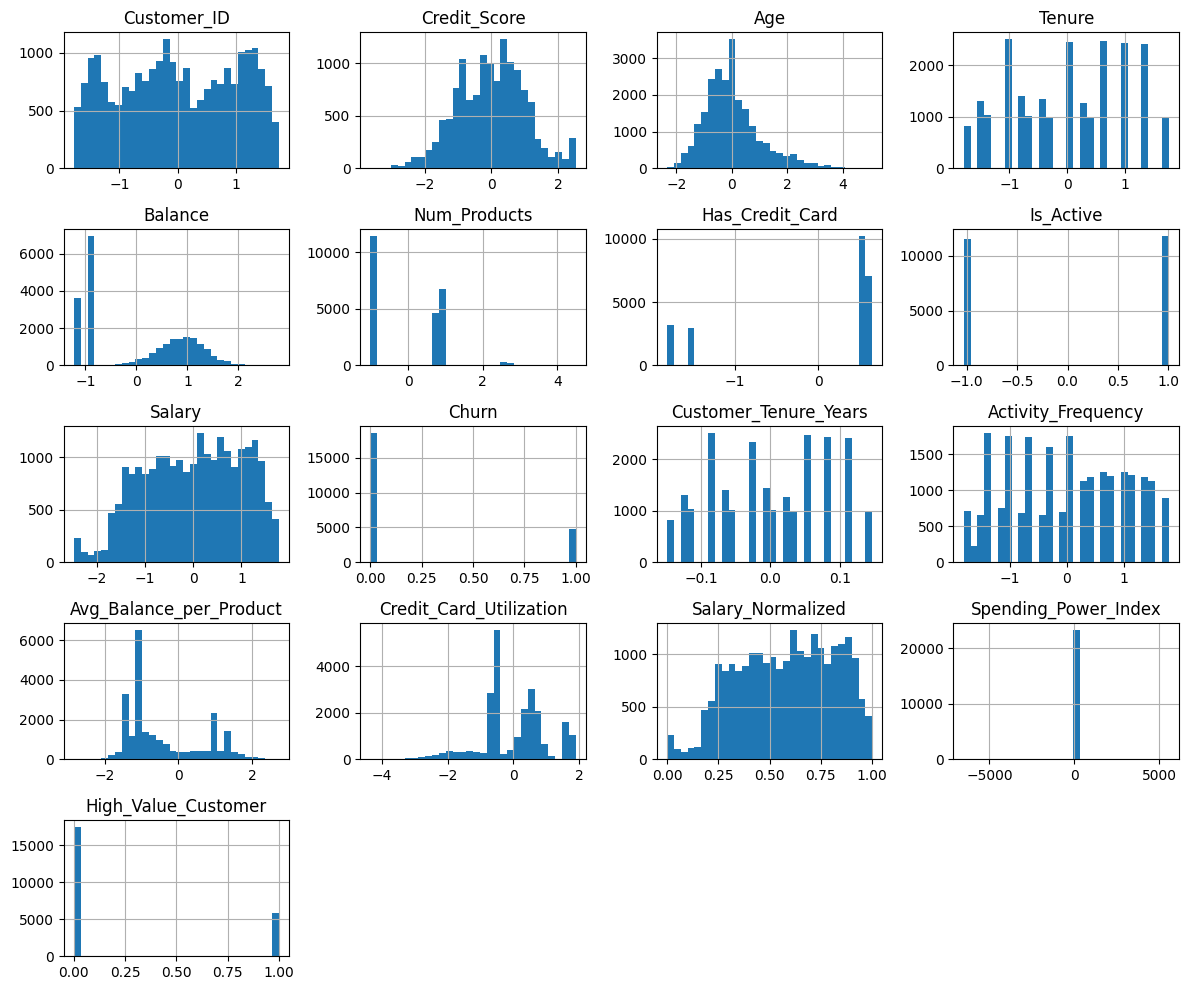

In [5]:
# Distribution of numerical features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 8))
df[numeric_cols].hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

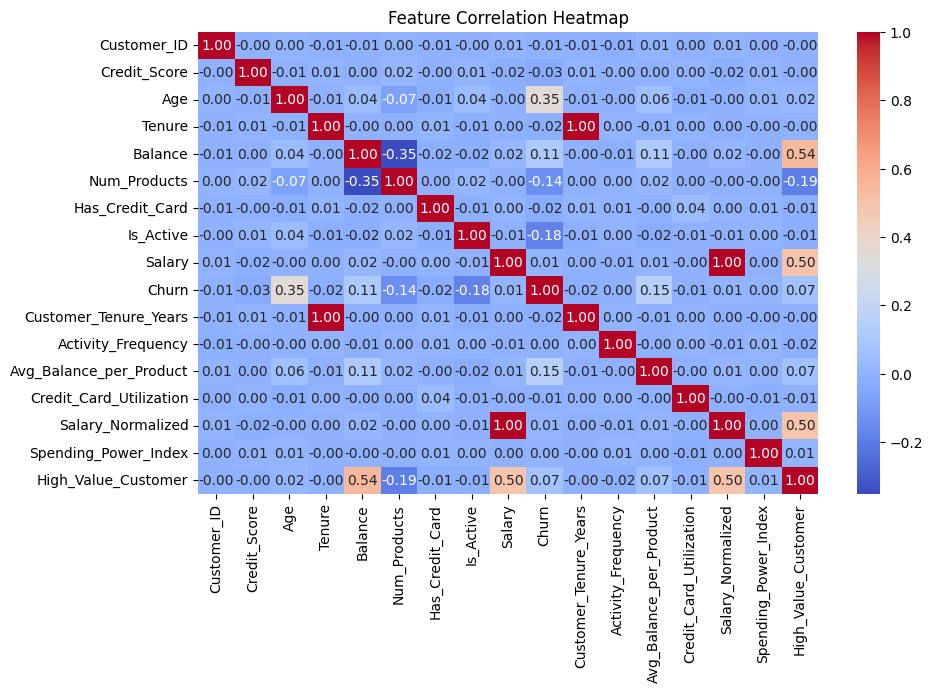

In [6]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

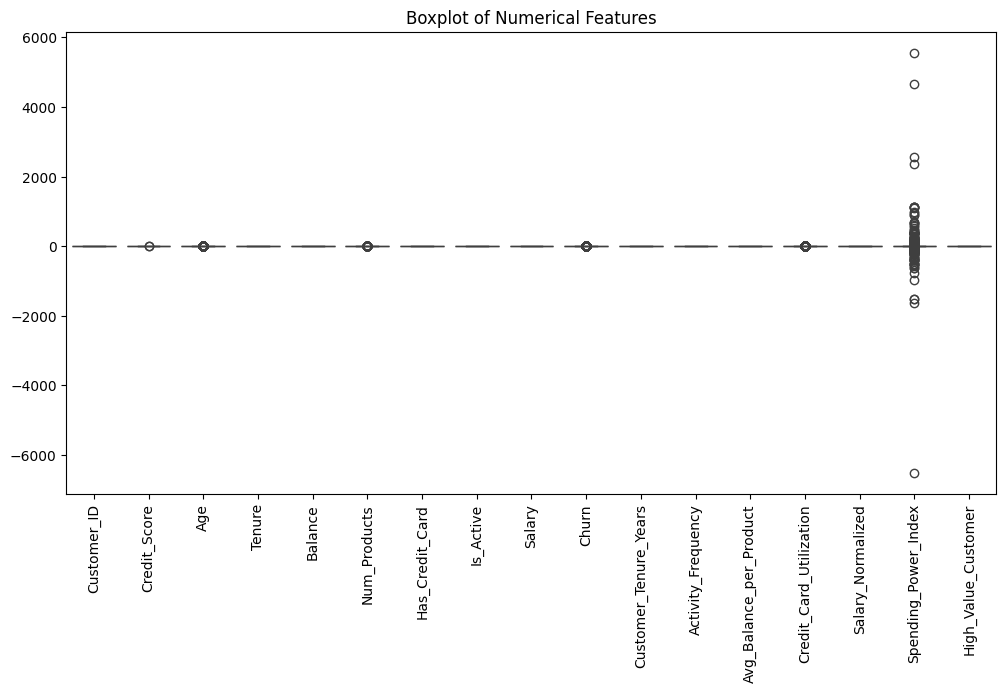

In [7]:
# Boxplot for outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

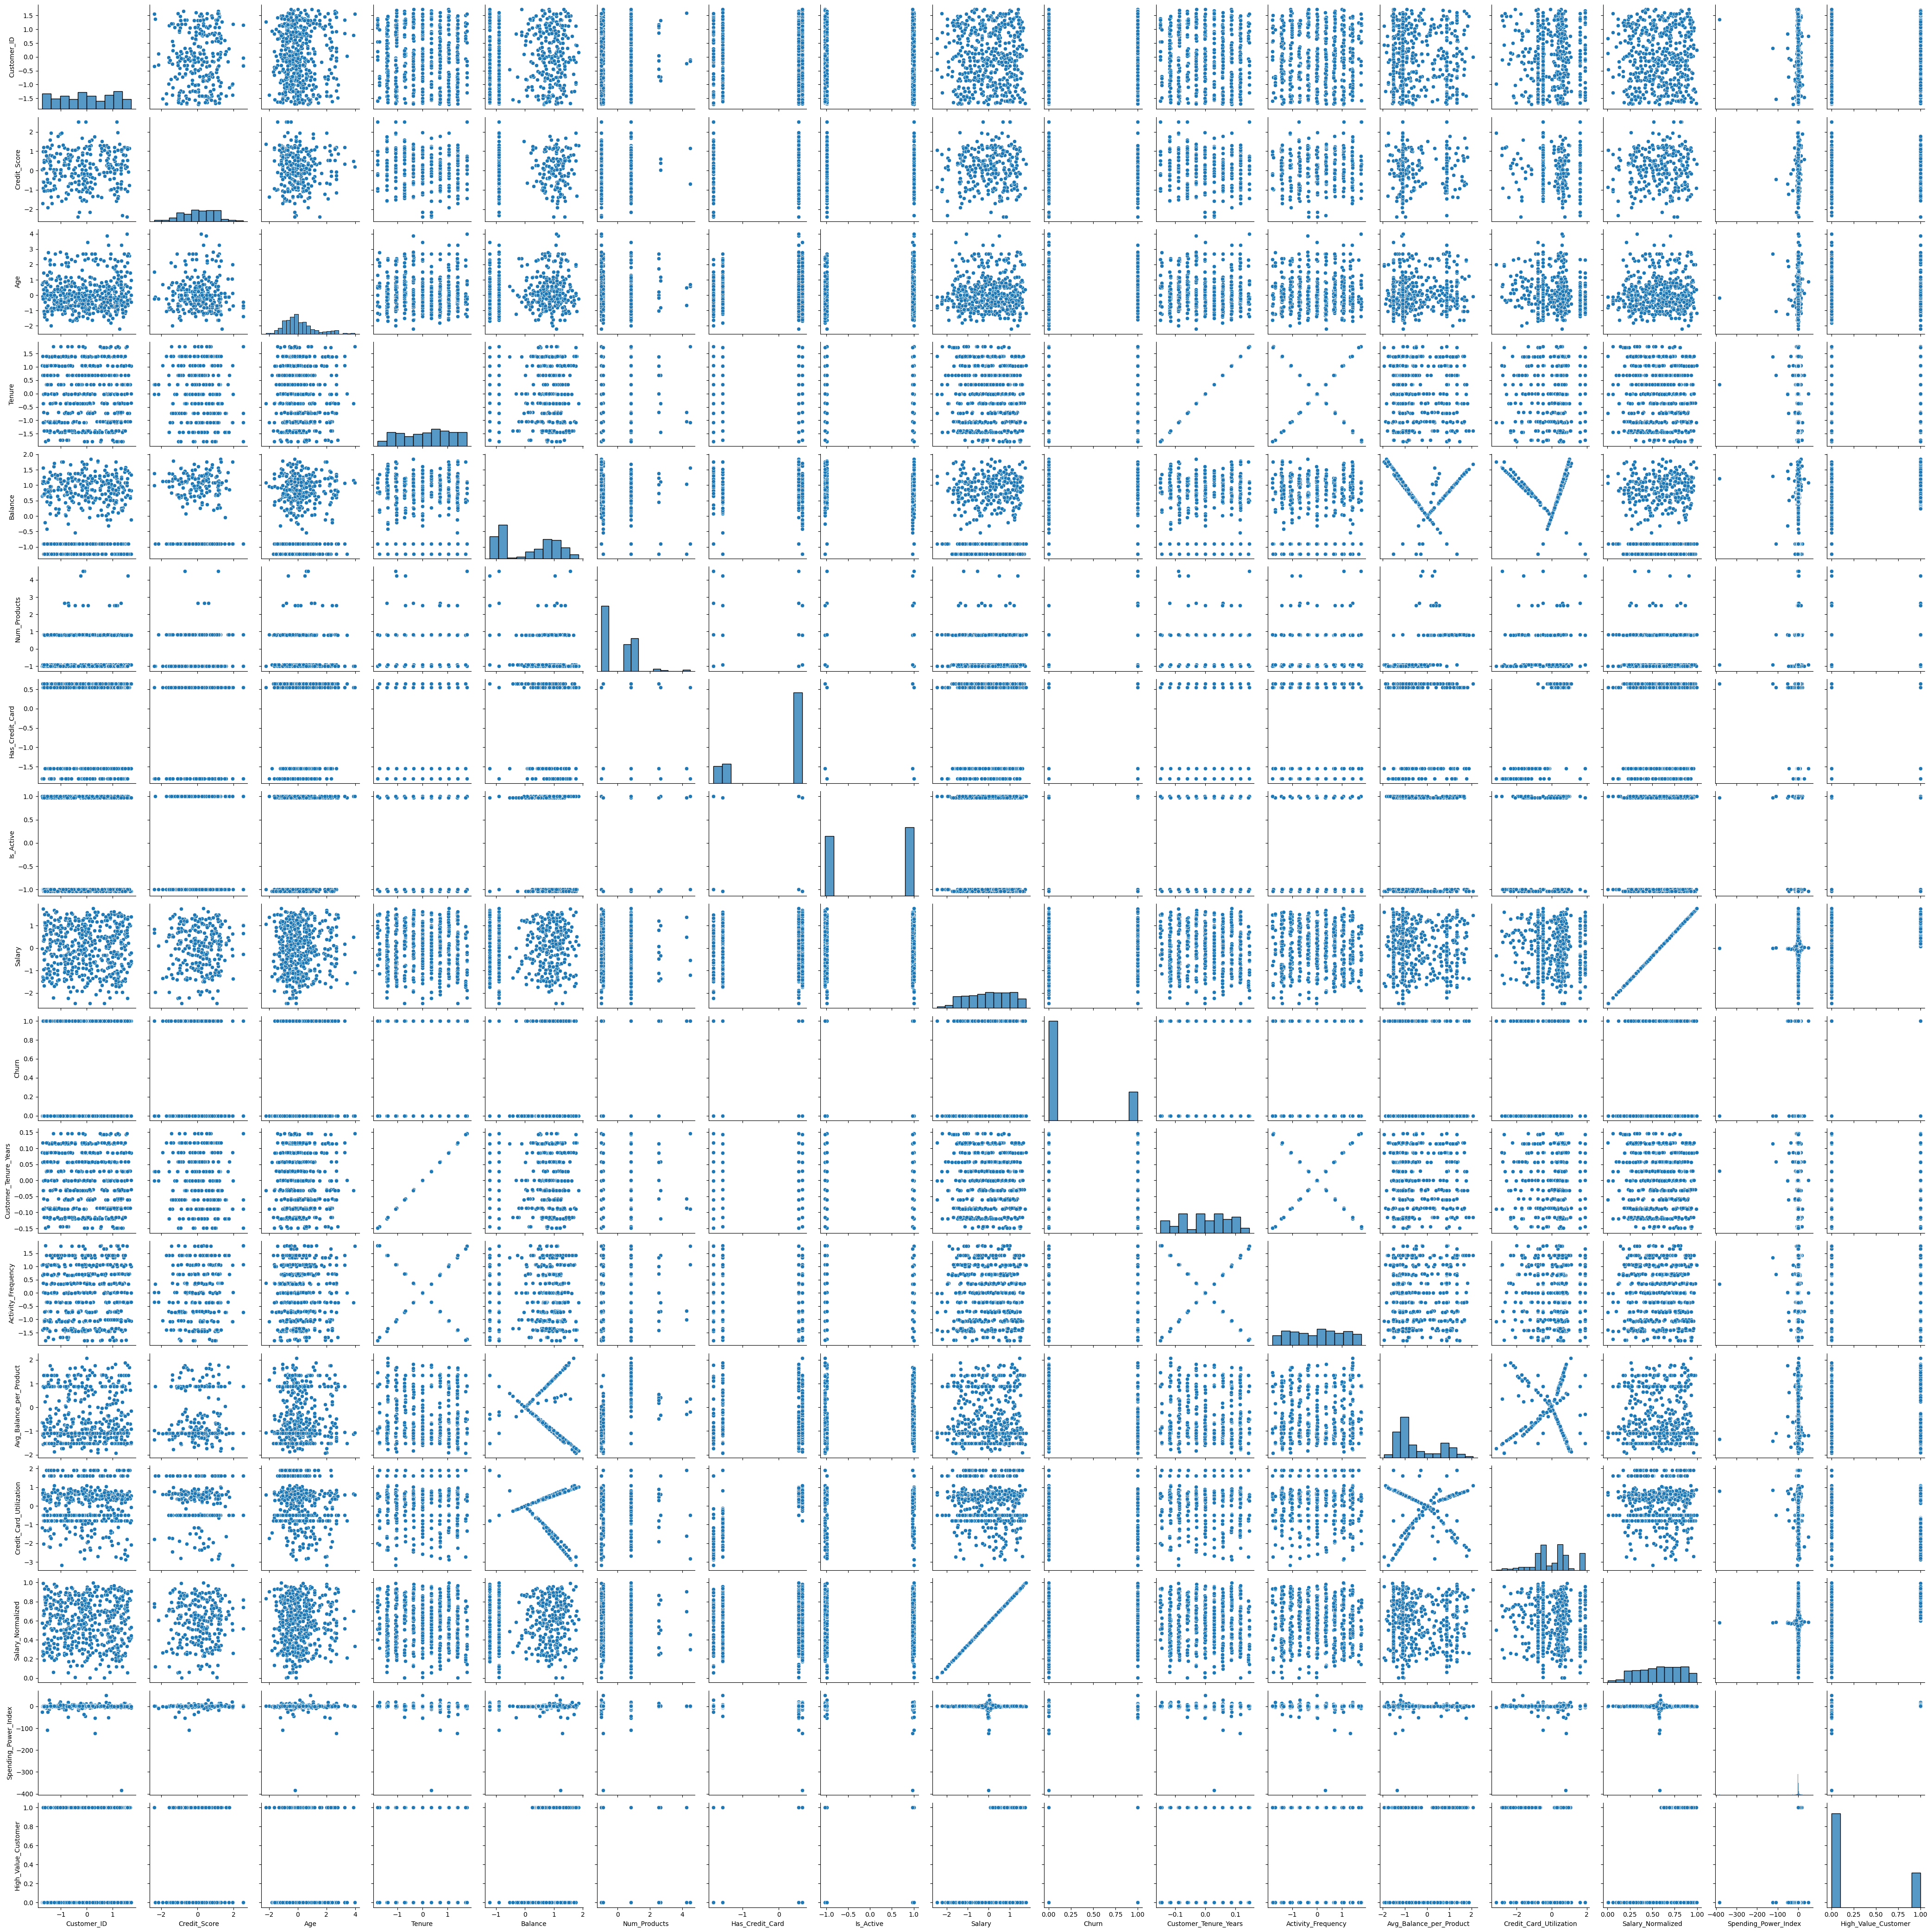

In [8]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)

    # Pairplot to check relationships (sample 500 rows for performance)
    sns.pairplot(df[numeric_cols].sample(500))
    plt.show()

In [10]:
# Save processed EDA data
csv_file_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data/eda/eda_summary.csv"))

# Save EDA summary as CSV
df.to_csv(csv_file_path, index=False)
print(f"✅ EDA summary saved as CSV at: {csv_file_path}")


✅ EDA summary saved as CSV at: \\wsl.localhost\Ubuntu\home\vineeth\customer_churn_airflow\CustomerChurn\data\eda\eda_summary.csv
